# Metode CBOW Pada Abstrak

# Import Library Embedding kata

Pertama-tama, kita mempersiapkan semua alat yang dibutuhkan. Kita mengimpor beberapa library penting: seperti pandas, numpy, gensim.models.Word2Vec dll


In [ ]:
import pandas as pd
from gensim.models import Word2Vec
import numpy as np


# Load dan preview dataset CSV

Setelah library siap, kita memuat dataset dari Google Drive (.csv) yang berisi abstrak penelitian yang sudah di-stem.

In [ ]:
# Load CSV dari Google Drive
df = pd.read_csv('/content/drive/MyDrive/PPW/manajemen_abstrak_stemmed.csv')

# Cek kolom (misalnya namanya 'abstrak' atau 'text')
df.head()


,abstrak_indo,cleaned,no_stopwords,stemmed
0,"ABSTRAK\r\nSatiyah, Pengaruh Faktor-faktor Pel...",abstrak satiyah pengaruh faktor faktor pelatih...,abstrak satiyah pengaruh faktor faktor pelatih...,abstrak satiyah pengaruh faktor faktor latih k...
1,Tujuan penelitian ini adalah untuk mengetahui ...,tujuan penelitian ini adalah untuk mengetahui ...,tujuan penelitian mengetahui persepsi brand as...,tuju teliti tahu persepsi brand association la...
2,Aplikasi nyata pemanfaatan teknologi informasi...,aplikasi nyata pemanfaatan teknologi informasi...,aplikasi nyata pemanfaatan teknologi informasi...,aplikasi nyata manfaat teknologi informasi kom...
3,Abstrak\r\nPenelitian ini menggunakan metode k...,abstrak penelitian ini menggunakan metode kuan...,abstrak penelitian menggunakan metode kuantita...,abstrak teliti guna metode kuantitatif tekan u...
4,"Abstrak\r\n\r\nAththaariq, Pengaruh Kompetensi...",abstrak aththaariq pengaruh kompetensi dosen t...,abstrak aththaariq pengaruh kompetensi dosen k...,abstrak aththaariq pengaruh kompetensi dosen k...


# Menampilkan Kolom Abstrak Indonesia

In [ ]:
df[['abstrak_indo', 'stemmed']].head(10)

,abstrak_indo,stemmed
0,"ABSTRAK\r\nSatiyah, Pengaruh Faktor-faktor Pel...",abstrak satiyah pengaruh faktor faktor latih k...
1,Tujuan penelitian ini adalah untuk mengetahui ...,tuju teliti tahu persepsi brand association la...
2,Aplikasi nyata pemanfaatan teknologi informasi...,aplikasi nyata manfaat teknologi informasi kom...
3,Abstrak\r\nPenelitian ini menggunakan metode k...,abstrak teliti guna metode kuantitatif tekan u...
4,"Abstrak\r\n\r\nAththaariq, Pengaruh Kompetensi...",abstrak aththaariq pengaruh kompetensi dosen k...
5,"ABSTRAK\r\nHaryono Arifin, Pengaruh Perilaku K...",abstrak haryono arifin pengaruh perilaku konsu...
6,"ABSTRAK\r\n\tDharma Abidin Syah,Kesimpulan: (1...",abstrak dharma abidin syah simpul dapat pengar...
7,ABSTRAK\r\n\r\nTujuan penelitian ini adalah un...,abstrak tuju teliti identifikasi variabel vari...
8,Hasil dari penelitian ini dari perhitungan Cre...,hasil teliti hitung credit risk ratio tunjuk n...
9,ABSTRAK\r\n\tTujuan penelitian ini adalah mend...,abstrak tuju teliti deskripsi inovasi unggul s...


# Tokenisasi teks dan representasi vektor rata-rata menggunakan Word2Vec

Setelah itu, dibuat kelas MyTokenizer yang berfungsi untuk tokenisasi sederhana: setiap teks diubah menjadi huruf kecil (lowercase) dan dipisahkan menjadi kata-kata menggunakan spasi.
Selanjutnya, dibuat kelas MeanEmbeddingVectorizer yang menerima model Word2Vec sebagai input. Kelas ini bertugas untuk mengubah setiap dokumen menjadi vektor tunggal dengan cara menghitung rata-rata embedding semua kata dalam dokumen tersebut. Pada metode transform, teks pertama-tama di-tokenisasi menggunakan MyTokenizer. Kemudian untuk setiap kata, hanya vektor dari kata yang ada di vocabulary Word2Vec yang diambil. Jika sebuah dokumen memiliki kata yang valid, rata-rata vektornya dihitung; jika tidak ada kata yang valid, digunakan vektor nol dengan panjang yang sama seperti dimensi embedding. kode ini membuat dua kelas: MyTokenizer untuk memecah teks menjadi daftar kata (token) dengan lowercase, dan MeanEmbeddingVectorizer untuk mengubah setiap dokumen menjadi vektor tunggal dengan menghitung rata-rata embedding kata dari model Word2Vec.

In [ ]:
import numpy as np

class MyTokenizer:
    def fit_transform(self, texts):
        # Tokenisasi sederhana: lowercase + split
        return [str(text).lower().split() for text in texts]

class MeanEmbeddingVectorizer:
    def __init__(self, word2vec_model):
        self.word2vec = word2vec_model
        # Perbaikan: gunakan vector_size (Gensim ≥ 4.0)
        self.dim = word2vec_model.wv.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_tokenized = MyTokenizer().fit_transform(X)
        embeddings = []
        for words in X_tokenized:
            # Ambil vektor hanya untuk kata yang ada di vocab
            valid_vectors = [
                self.word2vec.wv[word] for word in words
                if word in self.word2vec.wv
            ]
            if valid_vectors:
                embeddings.append(np.mean(valid_vectors, axis=0))
            else:
                embeddings.append(np.zeros(self.dim))
        return np.array(embeddings)

    def fit_transform(self, X, y=None):
        return self.transform(X)

In [ ]:
df.shape

(1026, 4)

# Word2Vec Embedding dari Korpus

Korpus yang sudah terbentuk kemudian digunakan untuk melatih model Word2Vec. Model ini belajar merepresentasikan setiap kata menjadi vektor numerik, dengan setiap kata direpresentasikan sebagai vektor berdimensi tertentu, misalnya 56. Kata-kata yang muncul minimal satu kali disertakan dalam vocabulary. Dengan begitu, setiap kata memiliki “koordinat” numerik yang memungkinkan kita mengukur kemiripan antar kata.

In [ ]:
corpus = []
for col in df.stemmed:
   word_list = col.split(" ")
   corpus.append(word_list)

#show first value
corpus[0:1]

#generate vectors from corpus
model = Word2Vec(corpus, min_count=1, vector_size = 56)

# Eksplorasi Word2Vec dan Mean

Setelah Word2Vec dilatih, setiap dokumen teks diubah menjadi vektor tunggal dengan menghitung rata-rata embedding dari semua kata di dokumen tersebut. Jika suatu dokumen tidak memiliki kata yang ada dalam vocabulary, maka digunakan vektor nol. Hasilnya, setiap dokumen memiliki tanda tangan numerik yang mewakili isinya secara keseluruhan.

In [ ]:
#explore embeddings using cosine similarity
model.wv.most_similar('pengaruh')

model.wv.most_similar_cosmul(positive = ['pengaruh', 'variabel'], negative = ['data'])

model.wv.doesnt_match("pengaruh variabel signifikan karyawan".split())

#save embeddings
filename = '/content/drive/MyDrive/PPW/abstrak_embd.txt'
model.wv.save_word2vec_format(filename, binary=False)

In [ ]:
mean_embedding_vectorizer = MeanEmbeddingVectorizer(model)
mean_embedded = mean_embedding_vectorizer.fit_transform(df['stemmed'])

# Hasil Embedding Dokumen

Vektor dokumen kemudian disimpan dalam kolom baru di DataFrame, sehingga setiap baris merepresentasikan satu dokumen. Kita juga menghitung panjang embedding untuk memastikan semua dokumen memiliki dimensi yang sama. Ini seperti menyimpan koordinat dokumen dalam lembar kerja untuk analisis lebih lanjut.

In [ ]:
df['array']=list(mean_embedded)
# hanya ambil kolom yang dibutuhkan
df_selected = df[['abstrak_indo', 'stemmed', 'array']]

# tampilkan 5 baris pertama
df_selected.head(5)

,abstrak_indo,stemmed,array
0,"ABSTRAK\r\nSatiyah, Pengaruh Faktor-faktor Pel...",abstrak satiyah pengaruh faktor faktor latih k...,"[-0.32989338, 0.64059424, 0.086310394, -0.0028..."
1,Tujuan penelitian ini adalah untuk mengetahui ...,tuju teliti tahu persepsi brand association la...,"[-0.27430135, 0.87129194, 0.3472955, -0.347421..."
2,Aplikasi nyata pemanfaatan teknologi informasi...,aplikasi nyata manfaat teknologi informasi kom...,"[-0.25174114, 0.6741423, 0.19320458, -0.102152..."
3,Abstrak\r\nPenelitian ini menggunakan metode k...,abstrak teliti guna metode kuantitatif tekan u...,"[-0.09479391, 1.2390169, 0.2622778, 0.28881437..."
4,"Abstrak\r\n\r\nAththaariq, Pengaruh Kompetensi...",abstrak aththaariq pengaruh kompetensi dosen k...,"[-0.22679718, 0.9910924, 0.324625, 0.06662122,..."


# Panjang Vektor Embedding per Dokumen

In [ ]:
df['embedding_length'] = df['array'].str.len()

In [ ]:
print(df['embedding_length'])

0       56
1       56
2       56
3       56
4       56
        ..
1021    56
1022    56
1023    56
1024    56
1025    56
Name: embedding_length, Length: 1026, dtype: int64


In [ ]:
df.shape

(1026, 6)

# list embedding

List embedding kemudian dipecah menjadi kolom terpisah, misalnya f1 hingga f56, agar dapat langsung digunakan sebagai fitur dalam machine learning. Baris tetap mewakili dokumen, dan setiap dimensi embedding menjadi kolom numerik yang bisa diproses secara matematis.

In [ ]:
num_features = len(df['array'].iloc[0])  # asumsi semua list punya panjang sama
columns = [f'f{i+1}' for i in range(num_features)]

# Inisialisasi dictionary untuk menampung data per kolom
data_dict = {col: [] for col in columns}

# Looping setiap baris di kolom 'embedding'
for embedding_list in df['array']:
    for i, value in enumerate(embedding_list):
        data_dict[f'f{i+1}'].append(value)

# Buat DataFrame dari dictionary
embedding_df = pd.DataFrame(data_dict)

embedding_df

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56
0,-0.329893,0.640594,0.086310,-0.002841,0.405490,-0.657743,0.492276,-0.337995,-0.257921,-0.262576,...,0.270040,1.266624,-0.078857,0.566032,-0.166385,1.010574,-0.255639,-0.625534,0.331930,-0.221466
1,-0.274301,0.871292,0.347295,-0.347421,0.123028,-0.745558,0.504970,-0.178939,0.098670,-0.325843,...,-0.153291,0.624514,-0.167879,0.375748,-0.234960,0.689593,-0.367929,-0.164656,0.430646,0.040259
2,-0.251741,0.674142,0.193205,-0.102152,0.267564,-0.616216,0.269900,-0.170972,-0.027344,-0.224174,...,0.061565,0.659564,-0.115288,0.330556,-0.270050,0.724413,-0.200412,-0.369668,0.460523,0.010833
3,-0.094794,1.239017,0.262278,0.288814,0.726071,-0.316773,1.017682,-0.312717,-0.143471,-0.414623,...,0.365876,1.470604,-0.310293,0.680712,0.013151,1.459200,-0.260571,-0.650081,0.208761,-0.231589
4,-0.226797,0.991092,0.324625,0.066621,0.399316,-0.528381,0.732066,-0.420509,-0.218369,-0.462590,...,0.159285,1.145023,-0.295372,0.472283,-0.196765,1.117756,-0.306022,-0.512240,0.361936,-0.228367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1021,-0.059136,0.914259,0.048667,0.065234,0.492818,-0.095028,0.500854,-0.623685,-0.042195,-0.507185,...,0.120815,0.629871,-0.368487,0.134759,0.140002,0.935803,-0.340698,-0.232511,0.099243,0.344951
1022,-0.134789,1.122963,0.036933,0.558383,1.212270,-0.107418,0.988959,-0.767599,-0.475421,-0.408179,...,0.727876,1.590393,-0.312152,0.472617,0.285035,1.797599,-0.124513,-0.963635,0.096092,-0.298215
1023,-0.086004,1.127381,0.468681,0.157996,0.641457,-0.378910,0.838145,-0.407329,-0.042804,-0.560009,...,0.231501,0.897566,-0.288234,0.400932,0.011008,1.234028,-0.280122,-0.365541,0.229666,0.077874
1024,-0.412312,1.217759,0.331435,-0.416322,-0.000190,-0.664869,0.292324,-0.172776,0.200550,-0.382157,...,0.160512,1.416856,-0.345160,0.339790,-0.113736,0.858489,-0.098427,-0.452109,0.466825,-0.259712


# gabung embedding numerik

In [ ]:
# gabungkan embedding numerik dengan kolom teks asli
final_df = pd.concat([df[['abstrak_indo', 'stemmed']], embedding_df], axis=1)

final_df.to_csv('/content/drive/MyDrive/PPW/abstrak_with_features.csv', index=False)
final_df.head()



,abstrak_indo,stemmed,f1,f2,f3,f4,f5,f6,f7,f8,...,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56
0,"ABSTRAK\r\nSatiyah, Pengaruh Faktor-faktor Pel...",abstrak satiyah pengaruh faktor faktor latih k...,-0.329893,0.640594,0.086310,-0.002841,0.405490,-0.657743,0.492276,-0.337995,...,0.270040,1.266624,-0.078857,0.566032,-0.166385,1.010574,-0.255639,-0.625534,0.331930,-0.221466
1,Tujuan penelitian ini adalah untuk mengetahui ...,tuju teliti tahu persepsi brand association la...,-0.274301,0.871292,0.347295,-0.347421,0.123028,-0.745558,0.504970,-0.178939,...,-0.153291,0.624514,-0.167879,0.375748,-0.234960,0.689593,-0.367929,-0.164656,0.430646,0.040259
2,Aplikasi nyata pemanfaatan teknologi informasi...,aplikasi nyata manfaat teknologi informasi kom...,-0.251741,0.674142,0.193205,-0.102152,0.267564,-0.616216,0.269900,-0.170972,...,0.061565,0.659564,-0.115288,0.330556,-0.270050,0.724413,-0.200412,-0.369668,0.460523,0.010833
3,Abstrak\r\nPenelitian ini menggunakan metode k...,abstrak teliti guna metode kuantitatif tekan u...,-0.094794,1.239017,0.262278,0.288814,0.726071,-0.316773,1.017682,-0.312717,...,0.365876,1.470604,-0.310293,0.680712,0.013151,1.459200,-0.260571,-0.650081,0.208761,-0.231589
4,"Abstrak\r\n\r\nAththaariq, Pengaruh Kompetensi...",abstrak aththaariq pengaruh kompetensi dosen k...,-0.226797,0.991092,0.324625,0.066621,0.399316,-0.528381,0.732066,-0.420509,...,0.159285,1.145023,-0.295372,0.472283,-0.196765,1.117756,-0.306022,-0.512240,0.361936,-0.228367


# Evaluasi

Selanjutnya, dokumen dikelompokkan menggunakan K-Means. Kita menentukan jumlah cluster, melatih model dengan semua kolom embedding numerik, dan menambahkan label cluster ke DataFrame. Dokumen yang memiliki kemiripan konten akan berada dalam cluster yang sama.menghitung Silhouette Score untuk menilai kualitas cluster. Nilai skor yang mendekati satu menunjukkan cluster yang terpisah dan rapi, sedangkan nilai mendekati nol menandakan dokumen berada di batas cluster. Skor negatif bisa menjadi indikasi cluster yang tumpang tindih atau salah

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(embedding_df.drop(columns=['cluster']), embedding_df['cluster'])
print("Silhouette Score:", score)


Silhouette Score: 0.35656834


Nilai Silhouette Score = 0.3565 ini menunjukkan cluster yang terbentuk cukup terpisah, tapi tidak sempurna.
ecara interpretasi:

1. Nilai berkisar dari -1 sampai 1.
2. Nilai mendekati 1 → cluster sangat rapih dan jelas terpisah.
3. Nilai mendekati 0 → titik berada di batas antar cluster, cluster kurang jelas.
4. Nilai negatif → cluster mungkin salah atau overlap.

# Visualisasi 2D Menggunakan PCA

Untuk memvisualisasikan hasil clustering, embedding direduksi dimensinya menjadi dua menggunakan PCA. Scatter plot dibuat dengan memberi warna berdasarkan label cluster, sehingga kita bisa melihat secara visual bagaimana cluster terbentuk di ruang 2D.

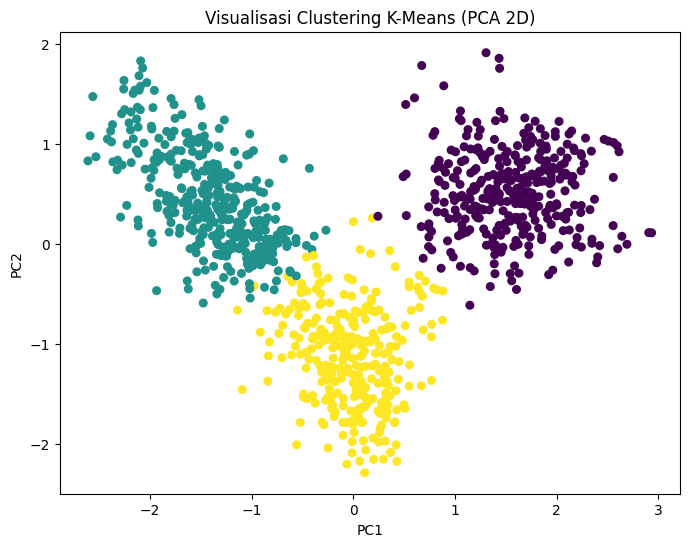

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Tentukan jumlah cluster
n_clusters = 3

# Inisialisasi dan fit KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(embedding_df)

# Tambahkan hasil cluster ke dataframe
embedding_df['cluster'] = kmeans.labels_

# =========================
# Visualisasi (pakai PCA biar 2D)
# =========================
pca = PCA(n_components=2)
reduced = pca.fit_transform(embedding_df.drop(columns=['cluster']))

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=embedding_df['cluster'], cmap='viridis', s=30)
plt.title("Visualisasi Clustering K-Means (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


1. Cluster biru, kuning, dan ungu umumnya terpisah, menunjukkan K-Means berhasil membagi dokumen menjadi kelompok yang relatif berbeda.

2. Ada beberapa titik yang agak dekat dengan cluster lain, misalnya beberapa titik kuning mendekati biru, ini menjelaskan kenapa Silhouette Score = 0.36. Titik-titik ini menandakan beberapa dokumen berada di tepi cluster, sehingga model kurang yakin ke cluster mana mereka masuk.